In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel(r"C:\Users\hp\MyPractice\Loan Prediction\loan_approved.xlsx")

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [5]:
df.shape

(614, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Loan_ID                 614 non-null    object 
 1   Gender                  601 non-null    object 
 2   Married                 611 non-null    object 
 3   Dependents              599 non-null    object 
 4   Education               614 non-null    object 
 5   Self_Employed           582 non-null    object 
 6   ApplicantIncome         614 non-null    int64  
 7   CoapplicantIncome       614 non-null    float64
 8   LoanAmount              592 non-null    float64
 9   Loan_Amount_Term        600 non-null    float64
 10  Credit_History          564 non-null    float64
 11  Property_Area           614 non-null    object 
 12  Loan_Status (Approved)  614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [7]:
df.isnull().sum()

Loan_ID                    0
Gender                    13
Married                    3
Dependents                15
Education                  0
Self_Employed             32
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                22
Loan_Amount_Term          14
Credit_History            50
Property_Area              0
Loan_Status (Approved)     0
dtype: int64

In [8]:
df.describe() 

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [9]:
df['ApplicantIncome']

0      5849
1      4583
2      3000
3      2583
4      6000
       ... 
609    2900
610    4106
611    8072
612    7583
613    4583
Name: ApplicantIncome, Length: 614, dtype: int64

In [10]:
df[['ApplicantIncome', 'LoanAmount']]

,ApplicantIncome,LoanAmount
0,5849,NaN
1,4583,128.0
2,3000,66.0
3,2583,120.0
4,6000,141.0
...,...,...
609,2900,71.0
610,4106,40.0
611,8072,253.0
612,7583,187.0


In [11]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status (Approved)'],
      dtype='object')

# Data Preprocessing

In [12]:
df.isnull().sum()

Loan_ID                    0
Gender                    13
Married                    3
Dependents                15
Education                  0
Self_Employed             32
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                22
Loan_Amount_Term          14
Credit_History            50
Property_Area              0
Loan_Status (Approved)     0
dtype: int64

In [13]:
# handle numerical missing data

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mean())

In [14]:
df.isnull().sum()

Loan_ID                    0
Gender                    13
Married                    3
Dependents                15
Education                  0
Self_Employed             32
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Loan_Amount_Term           0
Credit_History             0
Property_Area              0
Loan_Status (Approved)     0
dtype: int64

In [15]:
# handle categorical missing data

df['Gender'].mode()[0]

'Male'

In [16]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

In [17]:
df.isnull().sum()

Loan_ID                   0
Gender                    0
Married                   0
Dependents                0
Education                 0
Self_Employed             0
ApplicantIncome           0
CoapplicantIncome         0
LoanAmount                0
Loan_Amount_Term          0
Credit_History            0
Property_Area             0
Loan_Status (Approved)    0
dtype: int64

# EDA

<Axes: xlabel='Gender', ylabel='count'>

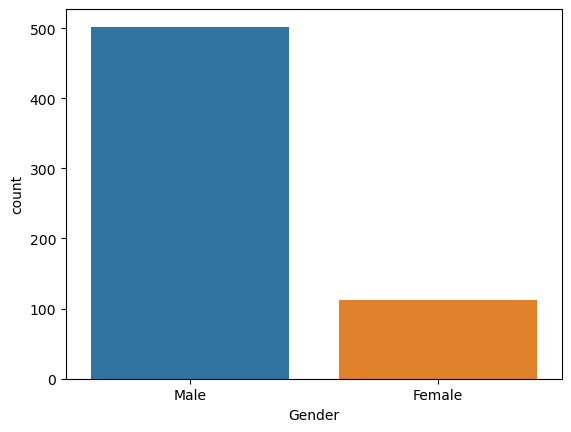

In [18]:
# CATEGORICAL DATA
import seaborn as sns
sns.countplot(x=df['Gender'])

<Axes: xlabel='Dependents', ylabel='count'>

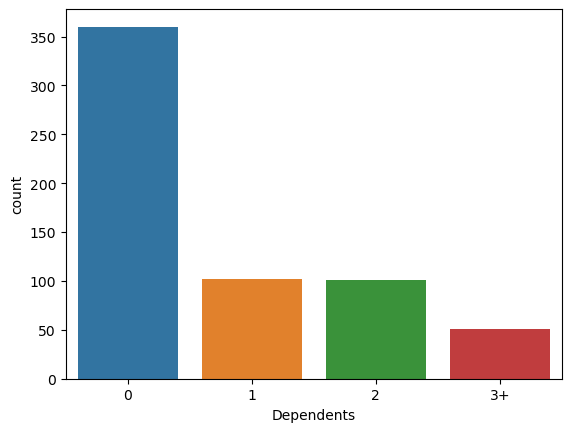

In [19]:
sns.countplot(x=df.Dependents)

<Axes: xlabel='Married', ylabel='count'>

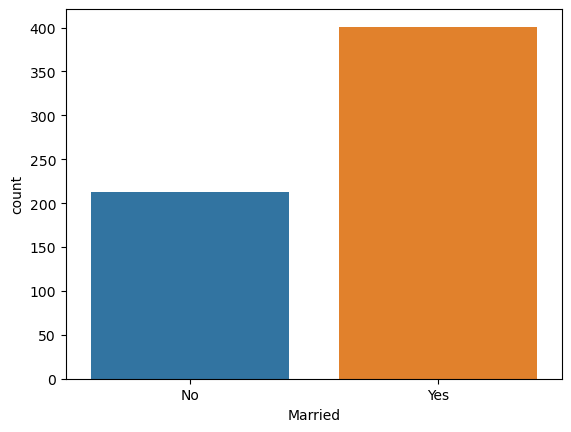

In [20]:
sns.countplot(x=df.Married)

<Axes: ylabel='Density'>

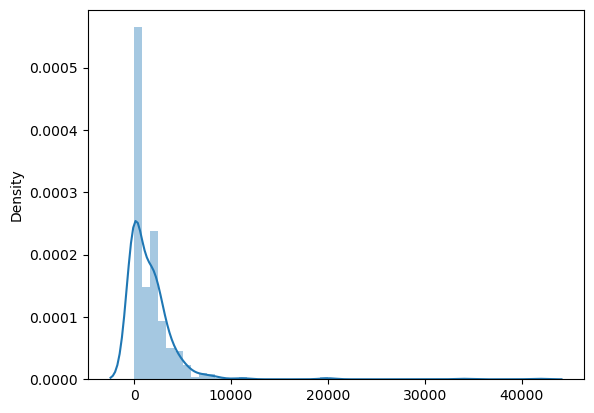

In [21]:
# Numerical data
# it tells how data is distributed
# we can check this for each numerical columns
sns.distplot(x=df.CoapplicantIncome)

<Axes: xlabel='LoanAmount', ylabel='Density'>

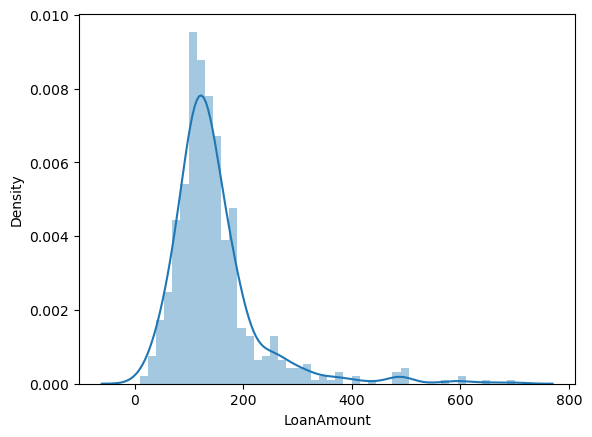

In [22]:
sns.distplot(df.LoanAmount)

<Axes: xlabel='Credit_History', ylabel='Density'>

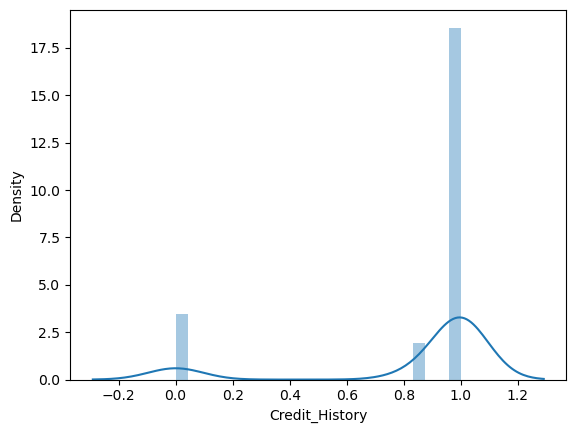

In [23]:
sns.distplot(df.Credit_History)

In [24]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y


In [25]:
# we can combine ApplicantIncome and CoapplicantIncome column
# create combine column
df['Total_income'] = df['ApplicantIncome']+df['CoapplicantIncome']

In [26]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved),Total_income
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y,6000.0


# Data Transformation

In [27]:
# we use logarithmec for normal distribution , we store log value
df['ApplicantIncomeLog'] = np.log(df['ApplicantIncome'])

<Axes: xlabel='ApplicantIncomeLog', ylabel='Density'>

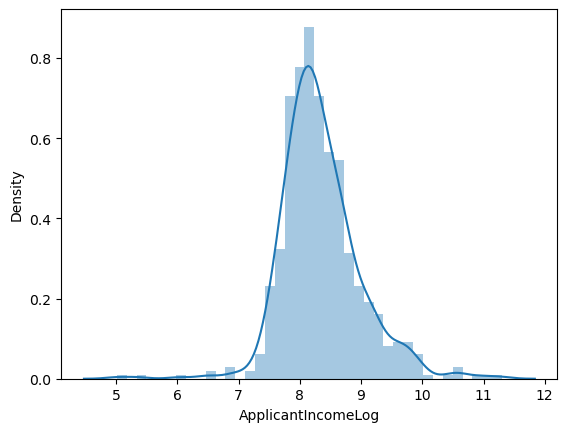

In [28]:
sns.distplot(df.ApplicantIncomeLog)

<Axes: xlabel='CoapplicantIncomeLog', ylabel='Count'>

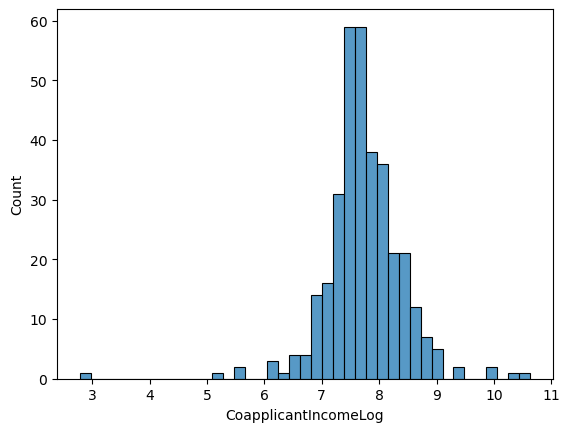

In [29]:
df['CoapplicantIncomeLog'] = np.log(df['CoapplicantIncome'])
sns.histplot(df.CoapplicantIncomeLog)

<Axes: xlabel='LoanAmountLog', ylabel='Density'>

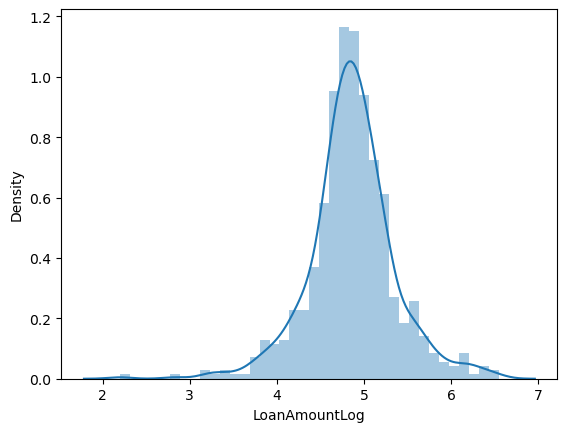

In [30]:
df['LoanAmountLog'] = np.log(df['LoanAmount'])
sns.distplot(df.LoanAmountLog)

<Axes: xlabel='Loan_Amount_Term_Log', ylabel='Density'>

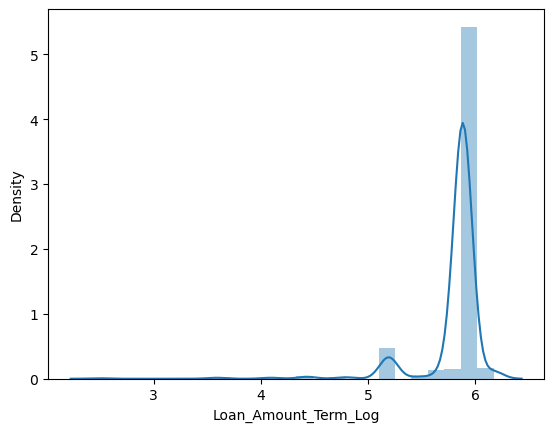

In [31]:
df['Loan_Amount_Term_Log'] = np.log(df['Loan_Amount_Term'])
sns.distplot(df.Loan_Amount_Term_Log)

<Axes: xlabel='Total_income_Log', ylabel='Density'>

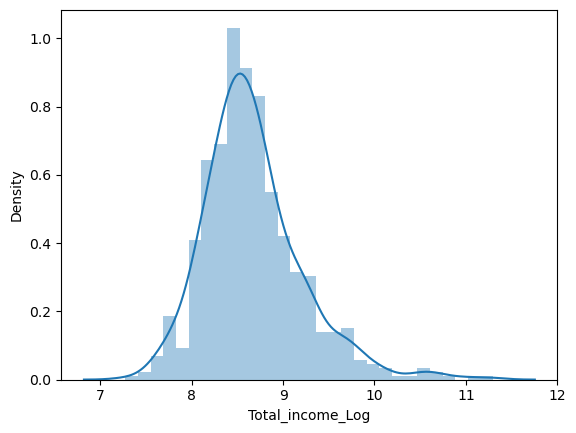

In [32]:
df['Total_income_Log'] = np.log(df['Total_income'])
sns.distplot(df.Total_income_Log)

In [33]:
df.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved),Total_income,ApplicantIncomeLog,CoapplicantIncomeLog,LoanAmountLog,Loan_Amount_Term_Log,Total_income_Log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y,5849.0,8.674026,-inf,4.986426,5.886104,8.674026
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N,6091.0,8.430109,7.31854,4.852030,5.886104,8.714568
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y,3000.0,8.006368,-inf,4.189655,5.886104,8.006368


In [34]:
# drop unnecessory columns because these are created columns with logarithmeich valuse
cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount','Loan_Amount_Term','Total_income','Loan_ID','CoapplicantIncomeLog']
df = df.drop(columns=cols,axis=1)

In [35]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status (Approved),ApplicantIncomeLog,LoanAmountLog,Loan_Amount_Term_Log,Total_income_Log
0,Male,No,0,Graduate,No,1.0,Urban,Y,8.674026,4.986426,5.886104,8.674026
1,Male,Yes,1,Graduate,No,1.0,Rural,N,8.430109,4.852030,5.886104,8.714568
2,Male,Yes,0,Graduate,Yes,1.0,Urban,Y,8.006368,4.189655,5.886104,8.006368
3,Male,Yes,0,Not Graduate,No,1.0,Urban,Y,7.856707,4.787492,5.886104,8.505323
4,Male,No,0,Graduate,No,1.0,Urban,Y,8.699515,4.948760,5.886104,8.699515


In [36]:
df.Gender.value_counts()

Male      502
Female    112
Name: Gender, dtype: int64

In [37]:
df.Education.value_counts()

Graduate        480
Not Graduate    134
Name: Education, dtype: int64

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Gender                  614 non-null    object 
 1   Married                 614 non-null    object 
 2   Dependents              614 non-null    object 
 3   Education               614 non-null    object 
 4   Self_Employed           614 non-null    object 
 5   Credit_History          614 non-null    float64
 6   Property_Area           614 non-null    object 
 7   Loan_Status (Approved)  614 non-null    object 
 8   ApplicantIncomeLog      614 non-null    float64
 9   LoanAmountLog           614 non-null    float64
 10  Loan_Amount_Term_Log    614 non-null    float64
 11  Total_income_Log        614 non-null    float64
dtypes: float64(5), object(7)
memory usage: 57.7+ KB


In [39]:
df.head(3)

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status (Approved),ApplicantIncomeLog,LoanAmountLog,Loan_Amount_Term_Log,Total_income_Log
0,Male,No,0,Graduate,No,1.0,Urban,Y,8.674026,4.986426,5.886104,8.674026
1,Male,Yes,1,Graduate,No,1.0,Rural,N,8.430109,4.852030,5.886104,8.714568
2,Male,Yes,0,Graduate,Yes,1.0,Urban,Y,8.006368,4.189655,5.886104,8.006368


# Handling categorical data

In [40]:
# these are categorical value , now we have to handle these so we have to one hot encoding
# we take object type column one by one

#cols = ['Gender','Married','Education','Self_Employed',"Property_Area","Loan_Status (Approved)","Dependents"]
# we create a loop to perform one hot encoding
#for col in cols:
 #   df[col] = pd.get_dummies(df, drop_first=True)

In [41]:
#d1 = pd.get_dummies(df['Gender'], drop_first=True)
#d2 = pd.get_dummies(df['Married'], drop_first=True)
#d3 = pd.get_dummies(df['Dependents'], drop_first=True)
#d4 = pd.get_dummies(df['Education'], drop_first=True)
#d5 = pd.get_dummies(df['Self_Employed'], drop_first=True)
#d6 = pd.get_dummies(df['Property_Area'], drop_first=True)

#df1 = pd.concat([df, d1, d2, d3, d4, d5, d6], axis=1)
#df=df1

#cols = ['Gender', 'Married', 'Dependents','Education','Self_Employed','Property_Area']
#df = df.drop(columns=cols,axis=1)

In [42]:
#df_y= pd.get_dummies(df['Loan_Status (Approved)'], drop_first=True)

In [43]:
df=pd.get_dummies(df,drop_first=True).astype(int)

In [44]:
df.head()

,Credit_History,ApplicantIncomeLog,LoanAmountLog,Loan_Amount_Term_Log,Total_income_Log,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status (Approved)_Y
0,1,8,4,5,8,1,0,0,0,0,0,0,0,1,1
1,1,8,4,5,8,1,1,1,0,0,0,0,0,0,0
2,1,8,4,5,8,1,1,0,0,0,0,1,0,1,1
3,1,7,4,5,8,1,1,0,0,0,1,0,0,1,1
4,1,8,4,5,8,1,0,0,0,0,0,0,0,1,1


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Credit_History            614 non-null    int32
 1   ApplicantIncomeLog        614 non-null    int32
 2   LoanAmountLog             614 non-null    int32
 3   Loan_Amount_Term_Log      614 non-null    int32
 4   Total_income_Log          614 non-null    int32
 5   Gender_Male               614 non-null    int32
 6   Married_Yes               614 non-null    int32
 7   Dependents_1              614 non-null    int32
 8   Dependents_2              614 non-null    int32
 9   Dependents_3+             614 non-null    int32
 10  Education_Not Graduate    614 non-null    int32
 11  Self_Employed_Yes         614 non-null    int32
 12  Property_Area_Semiurban   614 non-null    int32
 13  Property_Area_Urban       614 non-null    int32
 14  Loan_Status (Approved)_Y  614 non-null    

In [46]:
df.describe()

,Credit_History,ApplicantIncomeLog,LoanAmountLog,Loan_Amount_Term_Log,Total_income_Log,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status (Approved)_Y
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.773616,7.851792,4.317590,4.998371,8.167752,0.817590,0.653094,0.166124,0.164495,0.083062,0.218241,0.133550,0.379479,0.328990,0.687296
std,0.418832,0.708274,0.597807,0.258615,0.584913,0.386497,0.476373,0.372495,0.371027,0.276201,0.413389,0.340446,0.485653,0.470229,0.463973
min,0.000000,5.000000,2.000000,2.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,7.000000,4.000000,5.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,8.000000,4.000000,5.000000,8.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,8.000000,5.000000,5.000000,8.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,11.000000,6.000000,6.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Train Test split

In [47]:
x=df.iloc[:,:-1]
x.head(3)

,Credit_History,ApplicantIncomeLog,LoanAmountLog,Loan_Amount_Term_Log,Total_income_Log,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,1,8,4,5,8,1,0,0,0,0,0,0,0,1
1,1,8,4,5,8,1,1,1,0,0,0,0,0,0
2,1,8,4,5,8,1,1,0,0,0,0,1,0,1


In [48]:
y=df["Loan_Status (Approved)_Y"]

In [49]:
x.shape

(614, 14)

In [50]:
y.shape

(614,)

In [51]:
# For train test split

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42) # here for random state we can take from 1 to 1000

In [52]:
# x_train.head()
x_train.head(3)

,Credit_History,ApplicantIncomeLog,LoanAmountLog,Loan_Amount_Term_Log,Total_income_Log,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
92,1,8,4,5,8,1,1,0,1,0,1,0,0,1
304,1,8,4,5,8,1,0,0,0,0,0,0,0,0
68,1,8,4,4,8,1,1,0,0,1,1,1,0,1


In [53]:
y_train

92     1
304    1
68     1
15     1
211    0
      ..
71     1
106    1
270    1
435    1
102    1
Name: Loan_Status (Approved)_Y, Length: 460, dtype: int32

In [54]:
x_test

,Credit_History,ApplicantIncomeLog,LoanAmountLog,Loan_Amount_Term_Log,Total_income_Log,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
350,1,9,5,5,9,1,1,0,0,0,0,0,1,0
377,0,8,4,5,8,1,1,0,0,0,0,0,1,0
163,1,8,5,5,8,1,1,0,1,0,0,0,0,0
609,1,7,4,5,7,0,0,0,0,0,0,0,0,0
132,1,7,4,5,7,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,1,7,4,5,8,1,0,0,0,0,1,0,0,0
468,1,5,4,5,8,0,1,0,1,0,1,0,1,0
582,1,8,3,5,8,0,1,0,0,0,0,0,1,0
291,0,8,4,5,8,1,1,0,1,0,0,0,1,0


# Model Training

In [55]:
# After spliting data we made model training 
# we use Random forest classifier and train to model

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()

model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
# print accuracy of this model

print("Accuracy is", model.score(x_test, y_test)*100)

Accuracy is 68.18181818181817


In [57]:
# We take decision tree classifier

from sklearn.tree import DecisionTreeClassifier
model2 = DecisionTreeClassifier()
model2.fit(x_train, y_train)
print("Accuracy is", model2.score(x_test,y_test)*100)

Accuracy is 61.68831168831169


In [58]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
model3 = LogisticRegression()
model3.fit(x_train, y_train)
print("Accuracy is", model3.score(x_test, y_test)*100)

Accuracy is 74.67532467532467


In [59]:
# Confusion matrics

from sklearn.metrics import confusion_matrix
y_pred = model.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
cm

array([[23, 31],
       [18, 82]], dtype=int64)

In [60]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model3.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7467532467532467
              precision    recall  f1-score   support

           0       0.76      0.41      0.53        54
           1       0.74      0.93      0.83       100

    accuracy                           0.75       154
   macro avg       0.75      0.67      0.68       154
weighted avg       0.75      0.75      0.72       154



# Save Model

In [63]:
import pickle

In [64]:
# to save model import pickle

file = open("model.pkl", 'wb') # open file in write binary formate in which we can write anythink .
pickle.dump(model3, file) # Dump our model thet contain more accuracy than other model